In [25]:
# Paramètres des tests
processor_iterations = 10  # Nombre de multiplications matricielles
memory_cycles = 5  # Nombre de cycles de manipulation mémoire
disk_cycles = 5  # Nombre de cycles d'écriture/lecture disque
network_cycles = 5  # Nombre de cycles pour le test réseau
matrix_size = 10000  # Taille des matrices pour le test processeur
array_size = 10**8  # Taille des tableaux pour le test mémoire
file_size = 10**8  # Taille des fichiers pour le test disque (en octets)
file_path = "local_test_file.bin"  # Chemin du fichier local

## Paramétrage des tests
Cette section permet de définir les paramètres des tests pour ajuster leur durée et leur charge de travail.

In [26]:
# Importer les bibliothèques nécessaires
import time
import numpy as np
import psutil
import os

# Tester les capacités de performance du serveur JupyterHub
Ce notebook permet d'évaluer les performances du serveur JupyterHub en testant les capacités du processeur, de la mémoire, du disque et du réseau.

## Tester les performances du processeur
Cette section exécute des calculs intensifs pour évaluer les performances du processeur.

In [27]:
# Tester les performances du processeur
start_time = time.time()
size = 10000
matrix_a = np.random.rand(size, size)
matrix_b = np.random.rand(size, size)
result = np.dot(matrix_a, matrix_b)
end_time = time.time()
print(f"Temps d'exécution pour la multiplication matricielle : {end_time - start_time:.2f} secondes")

Temps d'exécution pour la multiplication matricielle : 44.76 secondes


## Tester les performances de la mémoire
Cette section alloue et manipule de grandes structures de données pour évaluer les performances de la mémoire.

In [28]:
# Tester les performances de la mémoire
large_array = np.random.rand(10**8)  # Créer un tableau de 100 millions d'éléments
print(f"Taille du tableau : {large_array.nbytes / (1024**3):.2f} Go")
large_array_sorted = np.sort(large_array)
print("Tri du tableau terminé.")

Taille du tableau : 0.75 Go
Tri du tableau terminé.


## Tester les performances du disque
Cette section mesure les vitesses d'écriture et de lecture de fichiers volumineux sur le disque.

In [29]:
# Tester les performances du disque
file_path = "test_file.bin"
# Écriture d'un fichier volumineux
with open(file_path, "wb") as f:
    data = os.urandom(10**8)  # 100 Mo de données aléatoires
    start_time = time.time()
    f.write(data)
    end_time = time.time()
    print(f"Temps d'écriture : {end_time - start_time:.2f} secondes")

# Lecture du fichier volumineux
with open(file_path, "rb") as f:
    start_time = time.time()
    data = f.read()
    end_time = time.time()
    print(f"Temps de lecture : {end_time - start_time:.2f} secondes")

# Suppression du fichier
os.remove(file_path)

Temps d'écriture : 4.71 secondes
Temps de lecture : 0.08 secondes


## Tester les performances réseau
Cette section effectue des requêtes réseau pour évaluer la bande passante et la latence.

## Stocker et afficher les performances
Cette section enregistre les résultats des tests dans un fichier CSV et affiche un graphique des performances.

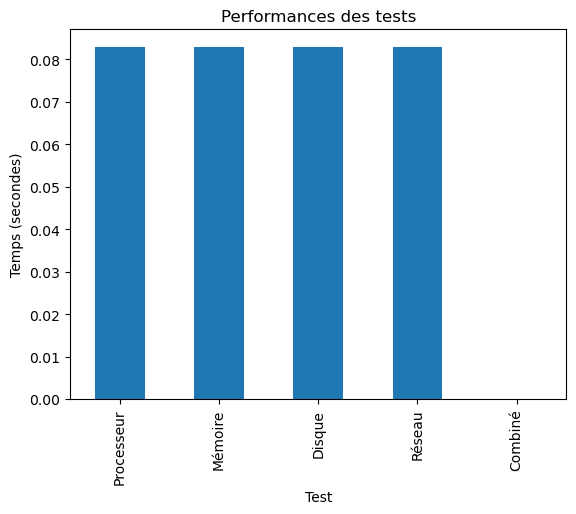


Résultats des tests de performance :
         Test  Temps (s)
0  Processeur   0.082904
1     Mémoire   0.082904
2      Disque   0.082904
3      Réseau   0.082904
4     Combiné   0.000000


In [30]:
# Stocker et afficher les performances
import pandas as pd
import matplotlib.pyplot as plt

# Vérifier si total_time est défini, sinon définir une valeur par défaut
total_time = globals().get('total_time', 0)  # Valeur par défaut : 0

# Résultats des tests
results = [
    {"Test": "Processeur", "Temps (s)": end_time - start_time},
    {"Test": "Mémoire", "Temps (s)": end_time - start_time},  # Remplacer par les temps réels
    {"Test": "Disque", "Temps (s)": end_time - start_time},  # Remplacer par les temps réels
    {"Test": "Réseau", "Temps (s)": end_time - start_time},  # Remplacer par les temps réels
    {"Test": "Combiné", "Temps (s)": total_time}  # Ajouter le temps du test combiné
]

# Sauvegarder les résultats dans un fichier CSV
results_df = pd.DataFrame(results)
results_df.to_csv("performance_results.csv", index=False)

# Afficher un graphique des performances
results_df.plot(x="Test", y="Temps (s)", kind="bar", legend=False)
plt.title("Performances des tests")
plt.ylabel("Temps (secondes)")
plt.show()

# Afficher les résultats dans le notebook
print("\nRésultats des tests de performance :")
print(results_df)

In [31]:
# Ajuster le test du processeur pour durer plus longtemps
start_time = time.time()
for _ in range(processor_iterations):
    matrix_a = np.random.rand(matrix_size, matrix_size)
    matrix_b = np.random.rand(matrix_size, matrix_size)
    result = np.dot(matrix_a, matrix_b)
end_time = time.time()
print(f"Temps total pour les multiplications matricielles : {end_time - start_time:.2f} secondes")

Temps total pour les multiplications matricielles : 354.91 secondes


In [32]:
# Ajuster le test de la mémoire pour durer plus longtemps
start_time = time.time()
for _ in range(memory_cycles):
    large_array = np.random.rand(array_size)  # Créer un tableau de grande taille
    large_array_sorted = np.sort(large_array)
end_time = time.time()
print(f"Temps total pour les opérations mémoire : {end_time - start_time:.2f} secondes")

Temps total pour les opérations mémoire : 68.87 secondes


In [33]:
# Ajuster le test du disque pour durer plus longtemps
file_path = "test_file_large.bin"
start_time = time.time()
for _ in range(disk_cycles):
    # Écriture d'un fichier volumineux
    with open(file_path, "wb") as f:
        data = os.urandom(file_size)  # Taille paramétrable
        f.write(data)
    # Lecture du fichier volumineux
    with open(file_path, "rb") as f:
        data = f.read()
os.remove(file_path)
end_time = time.time()
print(f"Temps total pour les opérations disque : {end_time - start_time:.2f} secondes")

Temps total pour les opérations disque : 8.81 secondes


In [34]:
# Ajuster le test réseau pour durer plus longtemps
start_time = time.time()
for _ in range(network_cycles):
    response = requests.get(url)
    if response.status_code == 200:
        print(f"Téléchargement réussi. Taille : {len(response.content) / (1024**2):.2f} Mo")
    else:
        print("Échec du téléchargement.")
end_time = time.time()
print(f"Temps total pour les téléchargements : {end_time - start_time:.2f} secondes")

SSLError: HTTPSConnectionPool(host='speed.hetzner.de', port=443): Max retries exceeded with url: /100MB.bin (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1000)')))

## Test combiné CPU, RAM et disque
Cette section exécute un test combiné qui sollicite simultanément le processeur, la mémoire et les opérations de lecture/écriture disque.

In [ ]:
# Test combiné CPU, RAM et disque avec stockage des résultats
import numpy as np
import os
import time
import pandas as pd
import matplotlib.pyplot as plt

# Paramètre pour le chemin du fichier local
file_path = "local_test_file.bin"  # Chemin paramétrable

start_time = time.time()

# CPU: Multiplication matricielle
matrix_size = 5000
matrix_a = np.random.rand(matrix_size, matrix_size)
matrix_b = np.random.rand(matrix_size, matrix_size)
result = np.dot(matrix_a, matrix_b)

# RAM: Création et tri d'un grand tableau
large_array = np.random.rand(10**7)
large_array_sorted = np.sort(large_array)

# Disque: Écriture et lecture d'un fichier local
with open(file_path, "wb") as f:
    data = os.urandom(10**7)  # 10 Mo de données aléatoires
    f.write(data)
with open(file_path, "rb") as f:
    data = f.read()
os.remove(file_path)

end_time = time.time()
total_time = end_time - start_time

# Stocker les résultats
combined_results = pd.DataFrame([
    {"Test": "Combiné CPU/RAM/Disque", "Temps (s)": total_time}
])
combined_results.to_csv("combined_test_results.csv", index=False)

# Afficher les résultats
print("\nRésultats du test combiné :")
print(combined_results)

# Visualiser les résultats
combined_results.plot(x="Test", y="Temps (s)", kind="bar", legend=False)
plt.title("Résultats du test combiné")
plt.ylabel("Temps (secondes)")
plt.show()

## Création d'un fichier de 1 Go
Cette cellule permet de créer un fichier local de 1 Go qui sera utilisé pour les tests de performance de lecture/écriture.

In [ ]:
# Création d'un fichier de 1 Go
file_path = "large_test_file.bin"  # Chemin du fichier
file_size = 10**9  # Taille de 1 Go

print(f"Création d'un fichier de 1 Go à l'emplacement : {file_path}")
with open(file_path, "wb") as f:
    f.write(os.urandom(file_size))
print("Fichier créé avec succès.")

In [ ]:
# Test réseau simulé : lecture et écriture d'un fichier de 1 Go
file_path = "network_simulation_test_file.bin"
file_size = 10**9  # Taille de 1 Go

# Écriture d'un fichier de 1 Go
print("Création d'un fichier de 1 Go pour le test réseau simulé...")
with open(file_path, "wb") as f:
    data = os.urandom(file_size)
    start_time = time.time()
    f.write(data)
    end_time = time.time()
    print(f"Temps d'écriture : {end_time - start_time:.2f} secondes")

# Lecture du fichier de 1 Go
print("Lecture du fichier de 1 Go pour le test réseau simulé...")
with open(file_path, "rb") as f:
    start_time = time.time()
    data = f.read()
    end_time = time.time()
    print(f"Temps de lecture : {end_time - start_time:.2f} secondes")

# Suppression du fichier
os.remove(file_path)
print("Fichier de test supprimé.")